In [27]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
current_dir = Path().resolve()
sys.path.append(current_dir.parent.parent.as_posix())

import os
from os import listdir
from os.path import isfile, join

# %% General setup
import pandas as pd
from pathlib import Path
from data_io import DataIO

import utils
import numpy as np
import plotly
import plotly.graph_objs as go
from utils import make_figure, save_fig
from scipy.stats import wilcoxon
from audrey.preprocessing.project_colors import ProjectColors

import re
import pickle
from psth_utils import *
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import Line2D
import matplotlib.patches as mpatches


# Load data
session_id = '251015'
data_dir = Path(r'/media/aleong/Audrey-experiments1') / session_id / 'Analysis'
figure_dir = data_dir / Path('Figures')

if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)
    print(f"Created the figure folder : {figure_dir}")

data_io = DataIO(data_dir)
loadname = data_dir / f'{session_id}_cells.csv'
data_io.load_session(session_id, load_pickle=False, load_waveforms=False)
#data_io.load_session(loadname, load_pickle=False, load_waveforms=False)
data_io.dump_as_pickle()

cells_df = pd.read_csv(loadname, header=[0, 1], index_col=0)
clrs = ProjectColors()

# INCLUDE_RANGE = 50  # include cells at max distance = 50 um

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Select the PA recordings to analyse

In [2]:
# Print available recording ids
print("Available recording ids:")
for rec_id in data_io.recording_ids:
    print(f"- {rec_id}")


# Manually select recordings to analyse
recording_nrs = [6, 7]

selected_rec_names = []
for r in recording_nrs:
    rec_name = None
    for rec_id in data_io.recording_ids:
        if f'_{r:03d}_' in rec_id:
            rec_name = rec_id
            selected_rec_names.append(rec_name)
            break

print(f"\nSelected recordings:")
for rec_name in selected_rec_names:
    print(f"- {rec_name}")

Available recording ids:
- 251015_A_006_noblocker_pa_prr_series
- 251015_A_007_noblocker_light_pa_series

Selected recordings:
- 251015_A_006_noblocker_pa_prr_series
- 251015_A_007_noblocker_light_pa_series


### Detect the electrode stimulation site with the most significant responses, per cell

In [3]:
# %% Detect electrode stim site with most significant responses, per cell
pref_ec_dict = {}

for cluster_id in data_io.cluster_df.index.values:
    pref_ec = None
    n_sig_pref_ec = None

    max_fr = None
    for ec in data_io.burst_df.electrode.unique():
        if pd.isna(ec):
            continue

        df = data_io.burst_df.query(f'electrode == {float(ec)}')
        tids = df.train_id.unique()
        n_sig = 0
        for tid in tids:
            if cells_df.loc[cluster_id, (tid, 'is_significant')] == True:
                n_sig += 1

        if n_sig > 1:
            if pref_ec is None or n_sig > n_sig_pref_ec:
                pref_ec = ec
                n_sig_pref_ec = n_sig

    pref_ec_dict[cluster_id] = pref_ec

print('Electrode stimulation site with the most significant responses per cell detected.\n\n------ End Of Cell ------')

Electrode stimulation site with the most significant responses per cell detected.

------ End Of Cell ------


# PSTH computation

N.B. : statistical testing generated with Claude Sonnet, not entirely sure of how reliable this is

Detection method for responses : +/- k * SD, or < 0.5 Hz if -k * SD < 0

In [ ]:
# ============================================================
# MAIN ANALYSIS
# ============================================================
'''
    All variables in capital letter are defined in psth_params.py
'''

print(f"\n{'='*80}")
print(f"PSTH ANALYSIS WITH STATISTICAL TESTING")
print(f"{'='*80}")
print(f"\nPARAMETERS:")
print(f"  Smoothing: ADAPTIVE based on baseline firing rate")
print(f"  Min duration: Excit = {MIN_DURATION_EXCIT_MS} ms, Inhib = {MIN_DURATION_INHIB_MS} ms")
print(f"  Min latency: {MIN_LATENCY_MS} ms")
print(f"  Min baseline for inhibition: {MIN_MU} Hz")

print(f"\nSTATISTICAL TESTING:")
if ENABLE_STATISTICAL_TESTS:
    print(f"  ENABLED")
    print(f"  Significance threshold: α = {SIGNIFICANCE_ALPHA}")
    print(f"  Bonferroni correction: {BONFERRONI_CORRECTION}")
    print(f"  Active tests:")
    for test_name, enabled in STATISTICAL_TESTS.items():
        if enabled:
            if test_name == 'bootstrap':
                print(f"    - Bootstrap ({N_BOOTSTRAP} iterations)")
            elif test_name == 't_test':
                print(f"    - Welch's t-test")
            elif test_name == 'permutation':
                print(f"    - Permutation test ({N_PERMUTATIONS} iterations)")
            elif test_name == 'sliding_window':
                print(f"    - Sliding window (window={WINDOW_SIZE_MS}ms, step={WINDOW_STEP_MS}ms)")
else:
    print(f"  DISABLED (threshold-based detection only)")

print(f"{'='*80}\n")


# ============================================================
# DATA LOADING
# ============================================================
# NOTE: These variables must be defined before running this script:
# - data_io
# - pref_ec_dict
# - selected_rec_names

print("\nLoading data...")
print("Expected variables:")
print("  - data_io")
print("  - pref_ec_dict: {cluster_id: electrode}")
print("  - selected_rec_names")
print("\nIf these are not defined, please define them before running this section.\n")


# ============================================================
# MAIN ANALYSIS LOOP
# ============================================================

cluster_ids = data_io.cluster_df.index.values
output_data = {}
cluster_baseline_rate = {}
method_comparison_data = []
all_results = []

for cluster_id in cluster_ids:
    
    # print(f"Processing cluster {cluster_id}")
    
    ec = pref_ec_dict.get(cluster_id)
    if ec is None:
        continue
    
    output_data[cluster_id] = {}
    
    for rec_name in selected_rec_names:
        
        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()
        
        if d_select.empty:
            continue
        
        # Determine stim
        if '_light_pa_' in rec_name:
            stim = "PA+light"
            dcs = d_select.laser_duty_cycle.unique()
        elif '_pa_' in rec_name:
            stim = "PA"
            dcs = d_select.duty_cycle.unique()
        else:
            continue
        
        for dc in sorted(dcs):
            
            # Get train info
            if stim == "PA+light":
                tid = d_select.query('laser_duty_cycle == @dc').iloc[0].train_id
                bd = data_io.burst_df.query('train_id == @tid').iloc[0].laser_burst_duration
            else:
                tid = d_select.query('duty_cycle == @dc').iloc[0].train_id
                bd = data_io.burst_df.query('train_id == @tid').iloc[0].burst_duration
            
            rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)
            stimtype = str(data_io.burst_df.query('train_id == @tid').iloc[0].stimtype)
            
            # Get burst onsets
            if stimtype in ('laser', 'padmd'):
                burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
            elif stimtype == 'dmd':
                burst_onsets = data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values
            else:
                continue
            
            # Get spike train for this cluster
            spiketrain = data_io.spiketimes[rec_id][cluster_id]
            
            # Extract spike times relative to stimulus onset
            spike_times = []
            binned = []
            
            for onset in burst_onsets:
                idx = np.where(
                    (spiketrain >= onset + t_edges[0]) &
                    (spiketrain < onset + t_edges[-1])
                )[0]
                
                rel = spiketrain[idx] - onset
                spike_times.append(rel)
                
                counts, _ = np.histogram(rel, bins=t_edges)
                binned.append(counts)
            
            if len(spike_times) == 0:
                continue
            
            binned = np.vstack(binned)
            
            # Calculate firing rate
            spike_counts_per_bin = binned.sum(axis=0)  # Total spikes per bin across trials
            rate = spike_counts_per_bin / (len(spike_times) * (BIN_SIZE_MS/1000))
            
            # Calculate baseline for adaptive smoothing
            baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
            baseline_rate_raw = rate[baseline_mask].mean()
            
            # Baseline filter
            if baseline_rate_raw < MIN_BASELINE_HZ:
                continue
            
            # Adaptive smoothing (depending of basal firing rate: low fr -> higher smoothing)
            adaptive_smooth_sd = get_adaptive_smooth_sd(baseline_rate_raw)
            rate_smooth = gaussian_filter1d(rate, adaptive_smooth_sd)
            
            # Recalculate baseline statistics on smoothed data
            mu = rate_smooth[baseline_mask].mean()
            sd = rate_smooth[baseline_mask].std(ddof=1)
            
            # # Calculate z-score
            # if sd > 0:
            #     zscore = (rate_smooth - mu) / sd
            # else:
            #     zscore = np.zeros_like(rate_smooth)
            
            # # Normalize z-score to [-1, 1] range using tanh
            # # This maps ±3 SD to ~±0.995, providing smooth saturation
            # zscore_normalized = np.tanh(zscore / 3)
            
            # cluster_baseline_rate[cluster_id] = mu
            
            # # OPTIONAL: Plot z-score before response classification
            # # Set PLOT_ZSCORE_DEBUG = True at top of script to enable
            # if False:  # Change to True to enable z-score debugging plots
            #     fig_zscore, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
                
            #     # Top panel: Raw firing rate
            #     ax1.plot(t_centers, rate_smooth, 'k-', linewidth=2, label='Firing rate')
            #     ax1.axhline(mu, color='gray', linestyle='--', alpha=0.6, label=f'Baseline ({mu:.1f} Hz)')
            #     ax1.axhline(mu + K_SD_EXCIT * sd, color='red', linestyle=':', alpha=0.6, label=f'+{K_SD_EXCIT}σ')
            #     ax1.axhline(mu - K_SD_INHIB * sd, color='blue', linestyle=':', alpha=0.6, label=f'-{K_SD_INHIB}σ')
            #     ax1.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='Stimulus')
            #     ax1.axvline(MIN_LATENCY_MS, color='gray', linestyle=':', linewidth=1, alpha=0.4, label='Detection start')
            #     ax1.set_ylabel('Firing Rate (Hz)', fontsize=11, fontweight='bold')
            #     ax1.set_title(f'Cluster {cluster_id} | {stim} | DC={dc} | Train {tid}', 
            #                  fontsize=12, fontweight='bold')
            #     ax1.legend(fontsize=8, loc='upper right')
            #     ax1.grid(alpha=0.3)
                
            #     # Bottom panel: Normalized z-score
            #     ax2.plot(t_centers, zscore_normalized, 'k-', linewidth=2, label='Normalized Z-score')
            #     ax2.axhline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
            #     ax2.axhline(0.48, color='red', linestyle=':', alpha=0.5, label='~+2σ (z≈0.48)')
            #     ax2.axhline(-0.48, color='blue', linestyle=':', alpha=0.5, label='~-2σ (z≈-0.48)')
            #     ax2.axhline(0.76, color='red', linestyle=':', alpha=0.3, label='~+3σ (z≈0.76)')
            #     ax2.axhline(-0.76, color='blue', linestyle=':', alpha=0.3, label='~-3σ (z≈-0.76)')
            #     ax2.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5)
            #     ax2.axvline(MIN_LATENCY_MS, color='gray', linestyle=':', linewidth=1, alpha=0.4)
            #     ax2.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
            #     ax2.set_ylabel('Normalized Z-score [-1, 1]', fontsize=11, fontweight='bold')
            #     ax2.set_ylim([-1.05, 1.05])
            #     ax2.legend(fontsize=8, loc='upper right')
            #     ax2.grid(alpha=0.3)
                
            #     plt.tight_layout()
            #     plt.show()
            
            # Detect latency
            baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
            spike_counts_baseline = spike_counts_per_bin[baseline_mask]
            results = detect_latency(rate_smooth, mu, sd, spike_counts_per_bin, spike_counts_baseline)

            resp_type = results['resp_type']
            latency_ms = results['latency_ms']
            
            # Skip if no significant response
            if not results['significant']:
                continue
            
            # Calculate response rate
            response_window = (t_centers >= 0) & (t_centers <= 100)
            response_rate = rate_smooth[response_window].mean()
            
            # Store in output_data
            output_data[cluster_id][tid] = dict(
                dc=dc,
                stim=stim,
                response_type=resp_type,
                latency_ms=latency_ms,
                response_rate=response_rate,
                baseline_rate=mu,
                baseline_sd=sd,
                smooth_sd=adaptive_smooth_sd,
                p_value=results['p_value'],
                test_results=results['test_results']
            )
            
            # Store for DataFrame
            all_results.append({
                'cluster_id': cluster_id,
                'train_id': tid,
                'uid': f"{cluster_id}_{tid}",
                'dc': dc,
                'stim': stim,
                'response_type': resp_type,
                'latency_ms': latency_ms,
                'response_rate': response_rate,
                'baseline_rate': mu,
                'p_value': results['p_value'],
                **{f'p_{k}': v for k, v in results['test_results'].items() if k != 'sliding_window_latency'}
            })
            
# ============================================================
# CREATE DATAFRAMES
# ============================================================

df = pd.DataFrame(all_results)

df.to_csv(f'{figure_dir}/{session_id}_psth_df.csv')

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"\nTotal responses detected: {len(df)}")
if len(df) > 0:
    print(f"  Excitatory: {len(df[df.response_type == 'excitatory'])} ({100*len(df[df.response_type == 'excitatory'])/len(df):.1f}%)")
    print(f"  Inhibitory: {len(df[df.response_type == 'inhibitory'])} ({100*len(df[df.response_type == 'inhibitory'])/len(df):.1f}%)")
    
    if ENABLE_STATISTICAL_TESTS:
        print(f"\nP-value statistics:")
        print(f"  Mean p-value: {df.p_value.mean():.4f}")
        print(f"  Median p-value: {df.p_value.median():.4f}")
        print(f"  Min p-value: {df.p_value.min():.4f}")
        print(f"  Max p-value: {df.p_value.max():.4f}")
        
        # Significance levels
        p001 = len(df[df.p_value < 0.001])
        p01 = len(df[(df.p_value >= 0.001) & (df.p_value < 0.01)])
        p05 = len(df[(df.p_value >= 0.01) & (df.p_value < 0.05)])
        
        print(f"\nSignificance levels:")
        print(f"  p < 0.001 (***): {p001} ({100*p001/len(df):.1f}%)")
        print(f"  0.001 ≤ p < 0.01 (**): {p01} ({100*p01/len(df):.1f}%)")
        print(f"  0.01 ≤ p < 0.05 (*): {p05} ({100*p05/len(df):.1f}%)")
        
        # Individual test statistics
        test_cols = [col for col in df.columns if col.startswith('p_')]
        if test_cols:
            print(f"\nIndividual test p-values (mean):")
            for col in test_cols:
                test_name = col.replace('p_', '').replace('_', ' ').title()
                print(f"  {test_name}: {df[col].mean():.4f}")
    
    print(f"\nBy stim:")
    for stim in df.stim.unique():
        cond_df = df[df.stim == stim]
        print(f"  {stim}: {len(cond_df)} responses")
        exc = len(cond_df[cond_df.response_type == 'excitatory'])
        inh = len(cond_df[cond_df.response_type == 'inhibitory'])
        print(f"    Excitatory: {exc}, Inhibitory: {inh}")
else:
    print("  No significant responses detected!")
    print("\nTroubleshooting tips:")
    print("  - Try setting ENABLE_STATISTICAL_TESTS = False to see threshold crossings")
    print("  - Increase SIGNIFICANCE_ALPHA (e.g., 0.10)")
    print("  - Disable BONFERRONI_CORRECTION")
    print("  - Check your data loading is working correctly")

print("="*80)


PSTH ANALYSIS WITH STATISTICAL TESTING

PARAMETERS:
  Smoothing: ADAPTIVE based on baseline firing rate
  Min duration: Excit = 10.0 ms, Inhib = 30.0 ms
  Min latency: 10.0 ms
  Min baseline for inhibition: 5.0 Hz

STATISTICAL TESTING:
  ENABLED
  Significance threshold: α = 0.05
  Bonferroni correction: True
  Active tests:
    - Bootstrap (1000 iterations)


Loading data...
Expected variables:
  - data_io
  - pref_ec_dict: {cluster_id: electrode}
  - selected_rec_names

If these are not defined, please define them before running this section.


RESULTS SUMMARY

Total responses detected: 446
  Excitatory: 366 (82.1%)
  Inhibitory: 80 (17.9%)

P-value statistics:
  Mean p-value: 0.0025
  Median p-value: 0.0000
  Min p-value: 0.0000
  Max p-value: 0.0420

Significance levels:
  p < 0.001 (***): 297 (66.6%)
  0.001 ≤ p < 0.01 (**): 107 (24.0%)
  0.01 ≤ p < 0.05 (*): 42 (9.4%)

Individual test p-values (mean):
  Value: 0.0025
  Bootstrap: 0.0025

By stim:
  PA: 244 responses
    Excitato

In [5]:
# ============================================================
# PRECOMPUTE WIDE (PIVOTED) DATAFRAMES
# ============================================================
# The resulting `df_wide` has one row per (cluster_id, dc) and columns like 
# latency_ms_pa / latency_ms_pl, response_type_pa / response_type_pl, etc.

# Build the primary wide table
df_wide = build_wide(df)

# Build wide table for excitatory and inhibitory response types
df_wide_exc = build_wide(df[df["response_type"] == "excitatory"])
df_wide_inh = build_wide(df[df["response_type"] == "inhibitory"])

print("Wide DataFrames ready:")
print(f"  df_wide        : {df_wide.shape[0]} rows × {df_wide.shape[1]} cols")
print(f"  df_wide_exc    : {df_wide_exc.shape[0]} rows × {df_wide_exc.shape[1]} cols")
print(f"  df_wide_inh    : {df_wide_inh.shape[0]} rows × {df_wide_inh.shape[1]} cols")

Wide DataFrames ready:
  df_wide        : 235 rows × 16 cols
  df_wide_exc    : 217 rows × 16 cols
  df_wide_inh    : 55 rows × 16 cols


# Z-score computation

In [6]:

# ============================================================
# Z-SCORE CALCULATION AND HEATMAP VISUALIZATION
# ============================================================

if len(df) > 0:
    print("\n" + "="*80)
    print("GENERATING Z-SCORE HEATMAPS")
    print("="*80)
    
    # Collect z-scored PSTHs for each cluster/stim/dc
    zscore_data = {}
    
    for cluster_id in cluster_ids:
        
        ec = pref_ec_dict.get(cluster_id)
        if ec is None:
            continue
        
        for rec_name in selected_rec_names:
            
            d_select = data_io.burst_df.query(
                'electrode == @ec and recording_name == @rec_name'
            ).copy()
            
            if d_select.empty:
                continue
            
            # Determine stim
            if '_light_pa_' in rec_name:
                stim = "PA+light"
                dcs = d_select.laser_duty_cycle.unique()
            elif '_pa_' in rec_name:
                stim = "PA"
                dcs = d_select.duty_cycle.unique()
            else:
                continue
            
            for dc in sorted(dcs):
                
                # Get train info
                if stim == "PA+light":
                    tid = d_select.query('laser_duty_cycle == @dc').iloc[0].train_id
                else:
                    tid = d_select.query('duty_cycle == @dc').iloc[0].train_id
                
                # Check if this response was significant
                response_key = (cluster_id, tid)
                if response_key not in [(r['cluster_id'], r['train_id']) for r in all_results]:
                    continue
                
                rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)
                stimtype = str(data_io.burst_df.query('train_id == @tid').iloc[0].stimtype)
                
                # Get burst onsets
                if stimtype in ('laser', 'padmd'):
                    burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
                elif stimtype == 'dmd':
                    burst_onsets = data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values
                else:
                    continue
                
                # Get spike train
                spiketrain = data_io.spiketimes[rec_id][cluster_id]
                
                # Extract spike times
                binned = []
                for onset in burst_onsets:
                    idx = np.where(
                        (spiketrain >= onset + t_edges[0]) &
                        (spiketrain < onset + t_edges[-1])
                    )[0]
                    rel = spiketrain[idx] - onset
                    counts, _ = np.histogram(rel, bins=t_edges)
                    binned.append(counts)
                
                if len(binned) == 0:
                    continue
                
                binned = np.vstack(binned)
                
                # Calculate firing rate
                rate = binned.sum(axis=0) / (len(binned) * (BIN_SIZE_MS/1000))
                
                # Calculate baseline
                baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
                baseline_rate = rate[baseline_mask].mean()
                
                if baseline_rate < MIN_BASELINE_HZ:
                    continue
                
                # Adaptive smoothing
                adaptive_smooth_sd = get_adaptive_smooth_sd(baseline_rate)
                rate_smooth = gaussian_filter1d(rate, adaptive_smooth_sd)
                
                # Calculate z-score
                mu = rate_smooth[baseline_mask].mean()
                sd = rate_smooth[baseline_mask].std(ddof=1)
                
                if sd > 0:
                    zscore = (rate_smooth - mu) / sd
                else:
                    zscore = np.zeros_like(rate_smooth)
                
                # Normalize z-score to [-1, 1] using tanh
                zscore_normalized = np.tanh(zscore / 3)
                
                # Latency
                latency = df.query('cluster_id == @cluster_id and train_id == @tid').iloc[0].latency_ms#.values

                # Store z-scored PSTH
                key = (cluster_id, stim, dc)
                zscore_data[key] = {
                    'zscore': zscore_normalized,  # Use normalized z-score
                    'zscore_raw': zscore,         # Keep raw z-score for reference
                    'rate': rate_smooth,
                    'cluster_id': cluster_id,
                    'stim': stim,
                    'dc': dc,
                    'train_id': tid,
                    'latency': latency
                }
    
    print(f"Collected {len(zscore_data)} z-scored PSTHs")

else:
    print("\nNo significant responses detected - skipping heatmap generation.")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


GENERATING Z-SCORE HEATMAPS
Collected 446 z-scored PSTHs

ANALYSIS COMPLETE


✓ Saved: /media/aleong/Audrey-experiments1/251015/Analysis/Figures/251015_heatmap_PA_light_sorted.png


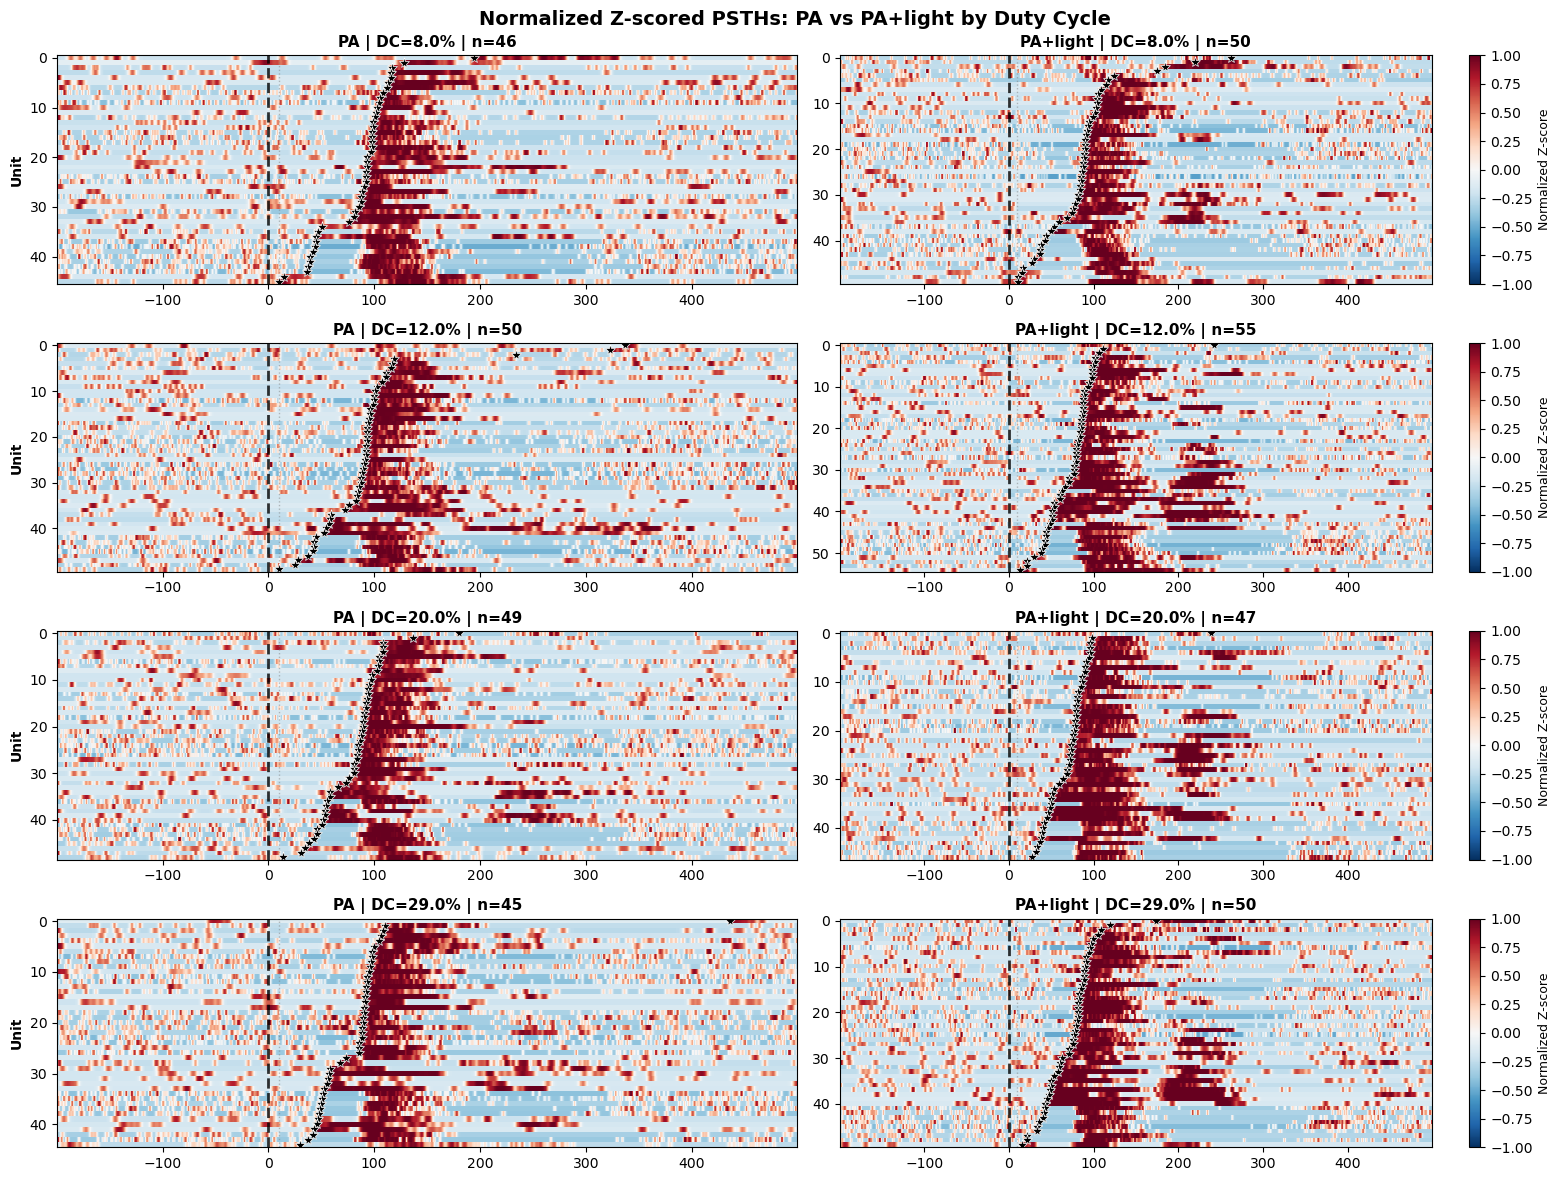


Z-SCORE HEATMAPS COMPLETE


In [7]:
# ============================================================
# HEATMAP: PA vs PA+light by DC (Latency Sorted)
# ============================================================

all_dcs = sorted(list(set([v['dc'] for v in zscore_data.values()])))

if len(all_dcs) > 0:
    fig, axes = plt.subplots(len(all_dcs) - 1, 2, figsize=(16, 3*(len(all_dcs) - 1)))
    if len(all_dcs) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, dc in enumerate(all_dcs):
        if dc == 37:
            continue
        
        for col_idx, stim in enumerate(['PA', 'PA+light']):
            ax = axes[idx, col_idx]
            
            # Get responses for this DC and stim
            dc_cond_responses = [(k, v) for k, v in zscore_data.items() 
                                if v['dc'] == dc and v['stim'] == stim]
            
            if len(dc_cond_responses) == 0:
                ax.text(0.5, 0.5, f'No data\nDC={dc}\n{stim}', 
                        ha='center', va='center', transform=ax.transAxes, fontsize=10)
                ax.set_title(f'{stim} | DC={dc}%', fontweight='bold')
                continue

            dc_cond_responses = sorted(dc_cond_responses, key=sort_key)

            n_units = len(dc_cond_responses)
            zscore_matrix = np.zeros((n_units, len(t_centers)))
            
            cluster_labels = []
            for i, (key, data) in enumerate(dc_cond_responses):
                zscore_matrix[i, :] = data['zscore']
                resp_type = data.get('response_type', '?')
                latency = data.get('latency', np.nan)
                resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
                cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {latency:.1f}ms)")
            
            # Plot heatmap
            im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
                            vmin=-1, vmax=1, interpolation='nearest',
                            extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
            
            # Add stimulus onset and detection window lines
            ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8)
            ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
            
            # Add latency markers (stars)
            for i, (key, data) in enumerate(dc_cond_responses):
                lat = data.get('latency', np.nan)
                if not np.isnan(lat):
                    ax.plot(lat, i, 'k*', markersize=8, markeredgecolor='white', markeredgewidth=0.5)
            
            # Labels
            if idx == len(all_dcs) - 1:
                ax.set_xlabel('Time (ms)', fontsize=10, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel('Unit', fontsize=10, fontweight='bold')
            
            ax.set_title(f'{stim} | DC={dc}% | n={n_units}', 
                        fontsize=11, fontweight='bold')
            
            # # Y-axis labels showing cluster ID, response type, and latency
            # ax.set_yticks(range(n_units))
            # ax.set_yticklabels(cluster_labels, fontsize=7)
            
            # Colorbar on right column only
            if col_idx == 1:
                cbar = plt.colorbar(im, ax=ax)
                cbar.set_label('Normalized Z-score', fontsize=9)
    
    plt.suptitle('Normalized Z-scored PSTHs: PA vs PA+light by Duty Cycle', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_name = f'{figure_dir}/{session_id}_heatmap_{stim.replace("+", "_")}_sorted.png'
    plt.savefig(save_name)
    print(f"✓ Saved: {save_name}")
    plt.show()

print("\n" + "="*80)
print("Z-SCORE HEATMAPS COMPLETE")
print("="*80)

# SUMMARY PLOTS

## Summary plot 1: latency comparison PA vs PA+light

✓ Saved: /media/aleong/Audrey-experiments1/251015/Analysis/Figures/251015_summary_latency_comparison.png


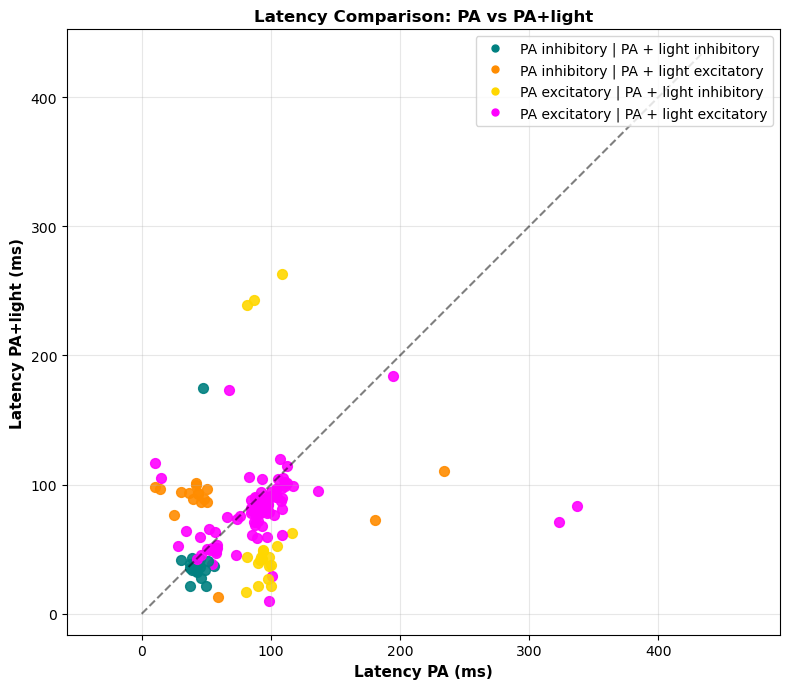

In [20]:
# ============================================================
# SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light
# ============================================================

RESPONSE_COLORS_PLOT1 = {
    ('inhibitory', 'inhibitory'): 'teal',
    ('inhibitory', 'excitatory'): 'darkorange',
    ('inhibitory', None):         'blue',
    ('excitatory', 'inhibitory'): 'gold',
    ('excitatory', 'excitatory'): 'magenta',
    ('excitatory', None):         'red',
    (None,         'inhibitory'): 'green',
    (None,         'excitatory'): 'purple',
}

plt.figure(figsize=(8, 7))

for dc in sorted(df_wide.index.get_level_values("dc").unique()):
    sub = df_wide.xs(dc, level="dc")   # one row per cluster_id
    if sub.empty:
        continue
    
    for _, r in sub.iterrows():
        resp_pa = r.get("response_type_pa", None)
        resp_pl = r.get("response_type_pl", None)
        resp_pa = resp_pa if isinstance(resp_pa, str) else None
        resp_pl = resp_pl if isinstance(resp_pl, str) else None
        color_base = RESPONSE_COLORS_PLOT1.get((resp_pa, resp_pl), 'grey')

        plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color_base, s=50, alpha=0.9)

legend_elements = [Line2D([0], [0], marker='o', color='teal',
                          markersize=5,
                          linestyle='None',
                          label='PA inhibitory | PA + light inhibitory',),
                   Line2D([0], [0], marker='o', color='darkorange',
                          markersize=5,
                          linestyle='None',
                          label='PA inhibitory | PA + light excitatory',),
                   Line2D([0], [0], marker='o', color='gold',
                          markersize=5,
                          linestyle='None',
                          label='PA excitatory | PA + light inhibitory',),
                   Line2D([0], [0], marker='o', color='magenta',
                          markersize=5,
                          linestyle='None',
                          label='PA excitatory | PA + light excitatory',),]

max_lat = df.latency_ms.max()
plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')

plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
plt.title("Latency Comparison: PA vs PA+light", fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.legend(handles=legend_elements, loc='upper right')
save_name = f'{figure_dir}/{session_id}_summary_latency_comparison.png'
plt.savefig(save_name, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {save_name}")
plt.show()

## Summary plot 2: excitatory response rate PA vs PA+light

✓ Saved: /media/aleong/Audrey-experiments1/251015/Analysis/Figures/251015_summary_excitatory_response_rate.png


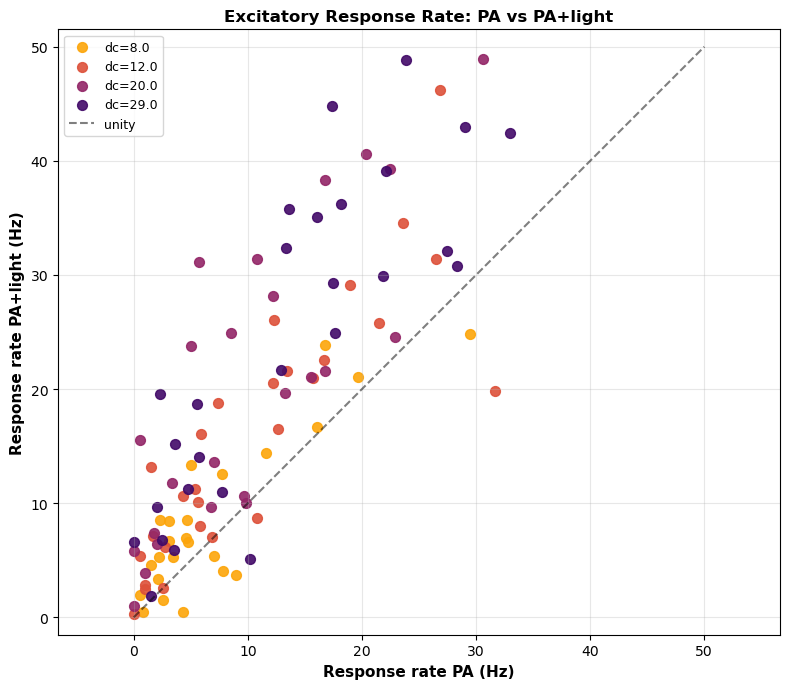

In [9]:
# ============================================================
# SUMMARY PLOT 2: EXCITATORY RESPONSE RATE
# ============================================================

plt.figure(figsize=(8, 7))

if not df_wide_exc.empty:
    for dc in sorted(df_wide_exc.index.get_level_values("dc").unique()):
        sub = df_wide_exc.xs(dc, level="dc")
        if sub.empty:
            continue

        color = color_dc(dc)
        plt.scatter(
            sub.response_rate_pa,
            sub.response_rate_pl,
            color=color, s=50, alpha=0.9, label=f"dc={dc}"
        )

    # Unity line
    # maxv = max(df_wide_exc.response_rate_pa.max(), df_wide_exc.response_rate_pl.max())
    maxv = 50
    
    plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')

    plt.xlabel("Response rate PA (Hz)", fontsize=11, fontweight='bold')
    plt.ylabel("Response rate PA+light (Hz)", fontsize=11, fontweight='bold')
    plt.title(f"Excitatory Response Rate: PA vs PA+light",
                fontsize=12, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    save_name = f'{figure_dir}/{session_id}_summary_excitatory_response_rate.png'
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_name}")
    plt.show()
else:
    print("No excitatory responses found for comparison plot.")

# Merging with the cell typing data

**/!\ Requires running the Omarre Standard Analysis pipeline**

Load the cell typing data

In [10]:
chirp_rec_nb     = 3
typing_directory = data_dir / Path(f"CellTyping_Analysis_rec_{chirp_rec_nb:03}")
typing_data_path = typing_directory / Path(f"{session_id}_PA-light5_cell_typing_data")
typing_df        = load_obj_as_df(typing_data_path)

Add the typing information into the PA df

In [11]:
# Match the Omarre pipeline index to the PA pipeline index
new_index = [f'uid_{session_id}_{i:03}' for i in typing_df.index]
typing_df.index = new_index

# Build wide version of df_merged
df_merged_wide = df_wide.copy()

# Temporary index to match the multi-index of df_merged_wide
tmp_idx = df_merged_wide.index.get_level_values('cluster_id')

# Add baden_type columns to df_merged_wide
df_merged_wide['baden_type'] = typing_df.loc[tmp_idx].baden_type.values

print(f"df_merged_wide : {df_merged_wide.shape[0]} rows × {df_merged_wide.shape[1]} cols")

df_merged_wide : 235 rows × 17 cols


In [22]:
df_merged_wide.to_csv(f"{data_dir}/{session_id}_summary_df_pa_light.csv")

## Summary plot: latency comparison depending on RGC type

✓ Saved: /media/aleong/Audrey-experiments1/251015/Analysis/Figures/251015_summary_latency_comparison_per_cell_type.png


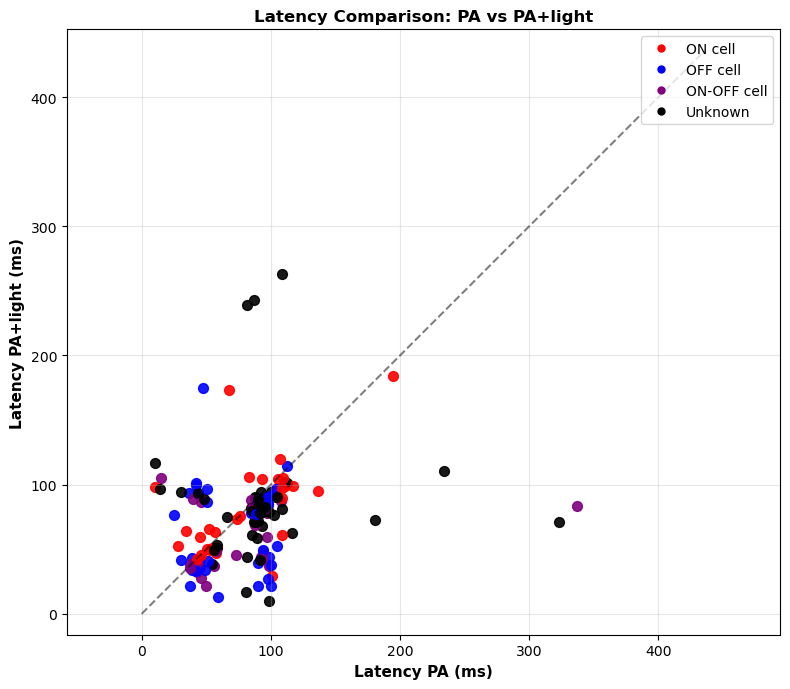

In [31]:
TYPE_COLORS = {
    'ON':     'red',
    'OFF':    'blue',
    'ON-OFF': 'purple',
}

# ============================================================
# SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light  (with badge_type)
# (uses precomputed df_merged_wide)
# ============================================================

plt.figure(figsize=(8, 7))

for dc in sorted(df_merged_wide.index.get_level_values("dc").unique()):
    sub = df_merged_wide.xs(dc, level="dc")
    if sub.empty:
        continue

    for _, r in sub.iterrows():
        baden_type = r.get('baden_type', None)
        cell_type  = extract_cell_type(baden_type)
        color_base = TYPE_COLORS.get(cell_type, 'black')

        plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color_base, s=50, alpha=0.9)

legend_elements = [Line2D([0], [0], marker='o', color='red', 
                          label='ON cell',
                          markersize=5,
                          linestyle='None'),
                   Line2D([0], [0], marker='o', color='blue', 
                          label='OFF cell',
                          markersize=5,
                          linestyle='None'),
                   Line2D([0], [0], marker='o', color='purple',
                          label='ON-OFF cell',
                          markersize=5,
                          linestyle='None'),
                   Line2D([0], [0], marker='o', color='black',
                          label='Unknown',
                          markersize=5,
                          linestyle='None'),]

# Unity line
max_lat = max(df_merged_wide.latency_ms_pa.max(), df_merged_wide.latency_ms_pl.max())
plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')

plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
plt.title("Latency Comparison: PA vs PA+light", fontsize=12, fontweight='bold')
plt.legend(handles=legend_elements, loc='upper right')
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
save_name = f'{figure_dir}/{session_id}_summary_latency_comparison_per_cell_type.png'
plt.savefig(save_name, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {save_name}")
plt.show()

## Summary plot: latency comparison per cell type, per DC

✓ Saved: /media/aleong/Audrey-experiments1/251015/Analysis/Figures/251015_summary_latency_comparison_per_cell_type_per_dc.png


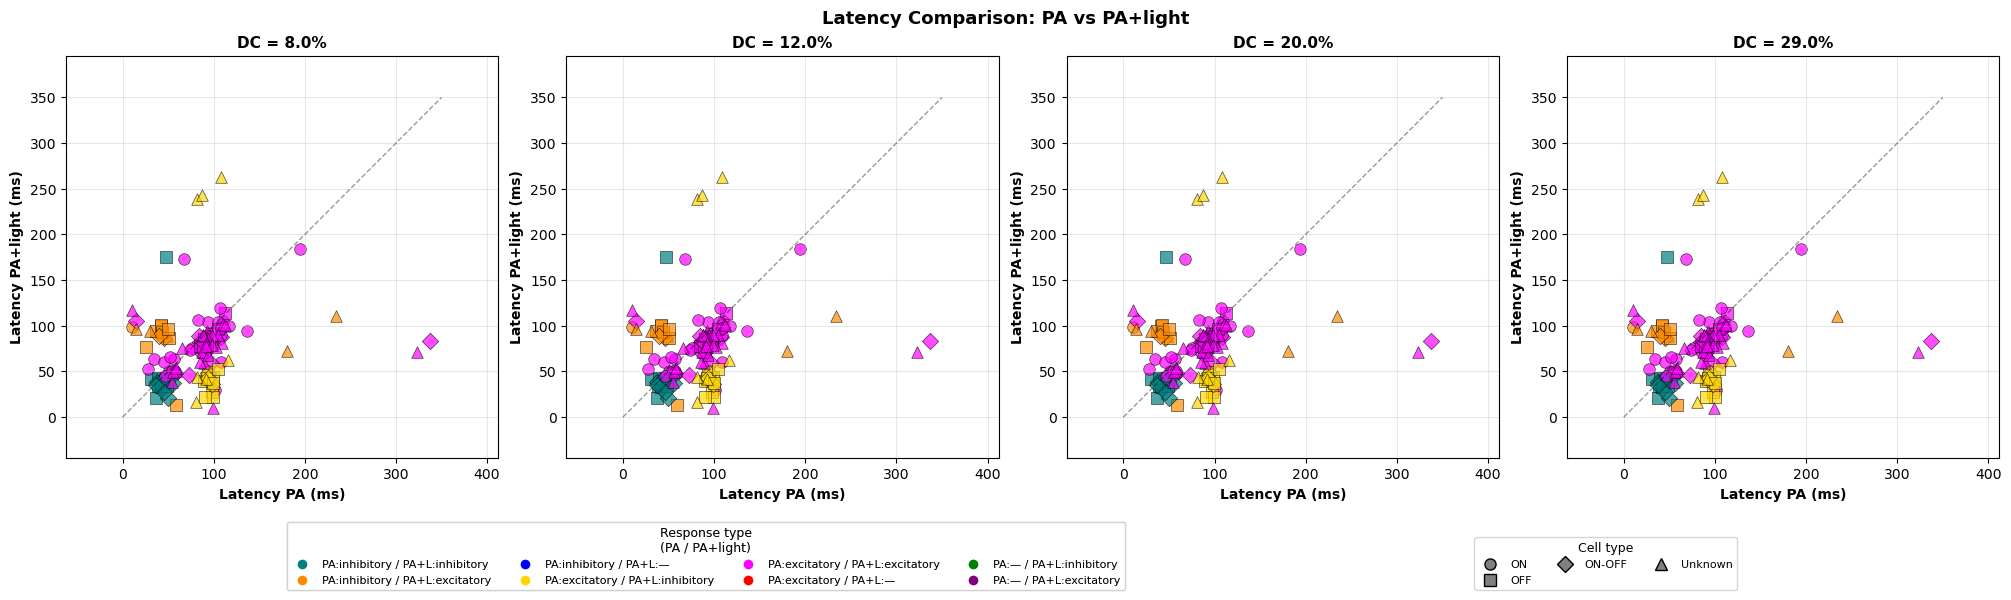

In [32]:
# ── Color encodes PA / PA+light response type combination ──────────────────
# ── Marker encodes cell type (ON / OFF) ────────────────────────────────────

RESPONSE_COLORS = {
    ('inhibitory', 'inhibitory'): 'teal',
    ('inhibitory', 'excitatory'): 'darkorange',
    ('inhibitory', None):         'blue',
    ('excitatory', 'inhibitory'): 'gold',
    ('excitatory', 'excitatory'): 'magenta',
    ('excitatory', None):         'red',
    (None,         'inhibitory'): 'green',
    (None,         'excitatory'): 'purple',
}

CELL_TYPE_MARKER = {
    'ON':    'o',   # circle
    'OFF':   's',   # square
    'ON-OFF':'D',   # diamond
}
CELL_TYPE_MARKER_DEFAULT = '^'   # triangle = unknown / not classified



# ── Filter and sort DCs (drop 37) ─────────────────────────────────────────
dcs = sorted([dc for dc in df_merged_wide.index.get_level_values(1).unique() if dc != 37])
n_dc = len(dcs)

fig, axes = plt.subplots(
    1, n_dc,
    figsize=(5 * n_dc, 5),
    sharex=False, sharey=False,
    constrained_layout=True,
)

# Make axes always iterable even for a single DC
if n_dc == 1:
    axes = [axes]

# Track global latency range for the unity line
#max_lat = max(df_merged_wide.latency_ms_pa.max(), df_merged_wide.latency_ms_pl.max())
max_lat = 350

for ax, dc in zip(axes, dcs):
    # ── Plot each cell ─────────────────────────────────────────────────────
    for _, r in df_merged_wide.iterrows():

        # Color from response-type combination
        resp_pa = r.get('response_type_pa', None)
        resp_pl = r.get('response_type_pl', None)
        # Normalise to None if NaN / not-a-string
        resp_pa = resp_pa if isinstance(resp_pa, str) else None
        resp_pl = resp_pl if isinstance(resp_pl, str) else None
        color = RESPONSE_COLORS.get((resp_pa, resp_pl), 'grey')

        # Marker from cell type
        baden_type = r.get('baden_type', None)
        cell_type = extract_cell_type(baden_type)
        marker = CELL_TYPE_MARKER.get(cell_type, CELL_TYPE_MARKER_DEFAULT)

        ax.scatter(
            r.latency_ms_pa, r.latency_ms_pl,
            color=color, marker=marker,
            s=70, alpha=0.7, linewidths=0.5, edgecolors='k',
        )

    # Unity line
    ax.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.4, lw=1, label='unity')

    ax.set_xlabel("Latency PA (ms)", fontsize=10, fontweight='bold')
    ax.set_ylabel("Latency PA+light (ms)", fontsize=10, fontweight='bold')
    ax.set_title(f"DC = {dc}%", fontsize=11, fontweight='bold')
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(alpha=0.3)

# ── Legends ────────────────────────────────────────────────────────────────
# Response-type color legend (placed on the last visible axis)
color_legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markersize=8, label=f"PA:{pa or '—'} / PA+L:{pl or '—'}")
    for (pa, pl), color in RESPONSE_COLORS.items()
]

# Cell-type marker legend
marker_legend_handles = [
    plt.Line2D([0], [0], marker=mk, color='w', markerfacecolor='grey',
               markeredgecolor='k', markersize=8, label=f"{ct}")
    for ct, mk in CELL_TYPE_MARKER.items()
] + [
    plt.Line2D([0], [0], marker=CELL_TYPE_MARKER_DEFAULT, color='w',
               markerfacecolor='grey', markeredgecolor='k',
               markersize=8, label='Unknown')
]

# Add both legends to the figure (outside the subplots)
leg1 = fig.legend(
    handles=color_legend_handles,
    title='Response type\n(PA / PA+light)',
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.35, -0.18),
    fontsize=8,
    title_fontsize=9,
    framealpha=0.8,
)
leg2 = fig.legend(
    handles=marker_legend_handles,
    title='Cell type',
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.80, -0.18),
    fontsize=8,
    title_fontsize=9,
    framealpha=0.8,
)
fig.add_artist(leg1)   # needed when two legends are added to the same figure

fig.suptitle("Latency Comparison: PA vs PA+light", fontsize=13, fontweight='bold')
save_name = f'{figure_dir}/{session_id}_summary_latency_comparison_per_cell_type_per_dc.png'
plt.savefig(save_name, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {save_name}")
plt.show()

## Response type count: ON / OFF / ON-OFF  ×  PA / PA+light (summary)

──── PA response counts (per cell) ────
resp_pa    Excitatory  Inhibitory  No response
cell_type                                     
ON                 15           0            1
OFF                 7           4            3
ON-OFF             11           2            1
Unknown            27           1            4 

──── PA+light response counts (per cell) ────
resp_pl    Excitatory  Inhibitory  No response
cell_type                                     
ON                 14           0            2
OFF                11           2            1
ON-OFF              8           4            2
Unknown            29           0            3
✓ Saved: /media/aleong/Audrey-experiments1/251015/Analysis/Figures/251015_response_counts_by_cell_type.png


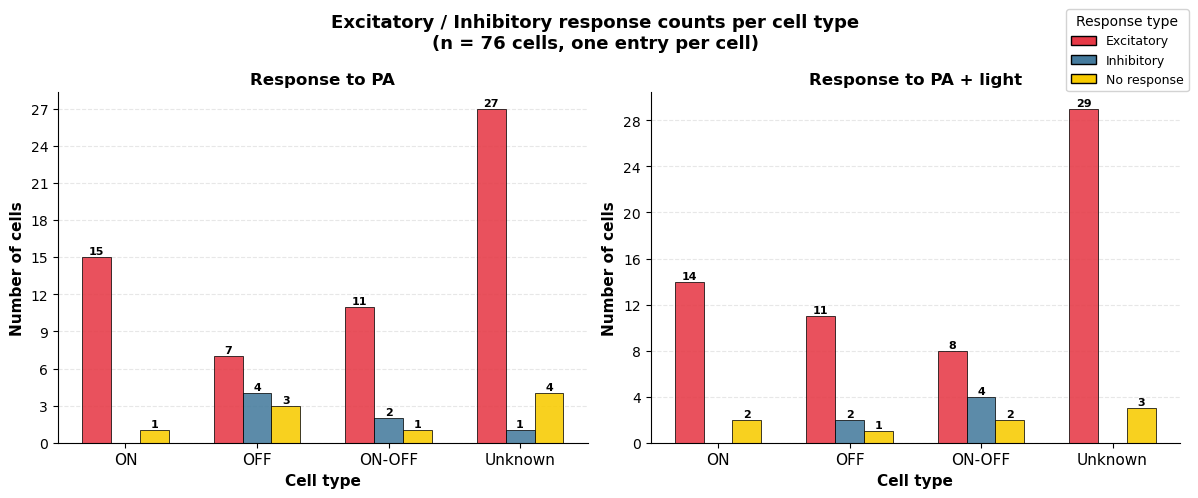

In [36]:
# ============================================================
# RESPONSE TYPE COUNT: ON / OFF / ON-OFF  ×  PA / PA+light
# ============================================================
# Uses df_merged_wide (one row per cluster_id × dc) built in cell 19.
# extract_cell_type(baden_type) must be defined (see cell 21).


# ── 1. Build a per-cell (cluster-level) summary ─────────────────────────────
#    For each cluster we take the *most common* response type across DCs,
#    so that every cell contributes exactly once per condition.

# Reset index so cluster_id is a column
df_cells = (
    df_merged_wide.reset_index()
    .groupby("cluster_id")
    .agg(
        response_type_pa=("response_type_pa", majority_response),
        response_type_pl=("response_type_pl", majority_response),
        baden_type=("baden_type", "first"),
    )
    .reset_index()
)

# ── 2. Classify each cell as ON / OFF / ON-OFF / Unknown ───────────────────
df_cells["cell_type"] = df_cells["baden_type"].apply(
    lambda bt: extract_cell_type(bt) or "Unknown"
)

# ── 3. Normalise response labels (None → "No response") ────────────────────
df_cells["resp_pa"] = df_cells["response_type_pa"].apply(norm_resp)
df_cells["resp_pl"] = df_cells["response_type_pl"].apply(norm_resp)

# ── 4. Pivot counts ─────────────────────────────────────────────────────────
CELL_TYPES  = ["ON", "OFF", "ON-OFF", "Unknown"]
RESP_LABELS = ["Excitatory", "Inhibitory", "No response"]

counts_pa = count_table(df_cells, "resp_pa")
counts_pl = count_table(df_cells, "resp_pl")

print("──── PA response counts (per cell) ────")
print(counts_pa,"\n")
print("──── PA+light response counts (per cell) ────")
print(counts_pl)

# ── 5. Grouped bar chart ────────────────────────────────────────────────────
RESP_COLORS = {
    "Excitatory":  "#E63946",   # red-ish
    "Inhibitory":  "#457B9D",   # blue
    "No response": "#F8CB00",   # yellow
}

cell_type_order = [ct for ct in CELL_TYPES if ct in df_cells["cell_type"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (counts, title, stim_label) in zip(
    axes,
    [
        (counts_pa, "Response to PA",        "PA"),
        (counts_pl, "Response to PA + light", "PA + light"),
    ]
):
    n_ct   = len(cell_type_order)
    n_resp = len(RESP_LABELS)
    x      = np.arange(n_ct)
    width  = 0.22
    offsets = np.linspace(-(n_resp - 1) / 2, (n_resp - 1) / 2, n_resp) * width

    for resp, offset in zip(RESP_LABELS, offsets):
        heights = [counts.loc[ct, resp] if ct in counts.index else 0
                   for ct in cell_type_order]
        bars = ax.bar(
            x + offset, heights, width,
            label=resp,
            color=RESP_COLORS[resp],
            edgecolor="k",
            linewidth=0.6,
            alpha=0.88,
        )
        # Annotate non-zero bars
        for bar, h in zip(bars, heights):
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.05,
                    str(int(h)),
                    ha="center", va="bottom",
                    fontsize=8, fontweight="bold",
                )

    ax.set_xticks(x)
    ax.set_xticklabels(cell_type_order, fontsize=11)
    ax.set_xlabel("Cell type", fontsize=11, fontweight="bold")
    ax.set_ylabel("Number of cells", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

# Shared legend
handles = [
    mpatches.Patch(facecolor=RESP_COLORS[r], edgecolor="k", label=r)
    for r in RESP_LABELS
]
fig.legend(
    handles=handles,
    title="Response type",
    loc="upper right",
    bbox_to_anchor=(1, 1),
    fontsize=9,
    title_fontsize=10,
    framealpha=0.85,
)

fig.suptitle(
    f"Excitatory / Inhibitory response counts per cell type\n"
    f"(n = {len(df_cells)} cells, one entry per cell)",
    fontsize=13, fontweight="bold",
)
fig.tight_layout()

save_name = f"{figure_dir}/{session_id}_response_counts_by_cell_type.png"
plt.savefig(save_name, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {save_name}")

plt.show()


## Response type count: ON / OFF / ON-OFF  ×  PA / PA+light (all DCs)


  OVERALL (majority vote per cell)

  [PA]
  Cell type         Excitatory      Inhibitory     No response
  ------------------------------------------------------------
  ON              15 ( 93.8%)       0 (  0.0%)       1 (  6.2%)    [n=16]
  OFF              7 ( 50.0%)       4 ( 28.6%)       3 ( 21.4%)    [n=14]
  ON-OFF          11 ( 78.6%)       2 ( 14.3%)       1 (  7.1%)    [n=14]
  Unknown         27 ( 84.4%)       1 (  3.1%)       4 ( 12.5%)    [n=32]

  [PA+light]
  Cell type         Excitatory      Inhibitory     No response
  ------------------------------------------------------------
  ON              14 ( 87.5%)       0 (  0.0%)       2 ( 12.5%)    [n=16]
  OFF             11 ( 78.6%)       2 ( 14.3%)       1 (  7.1%)    [n=14]
  ON-OFF           8 ( 57.1%)       4 ( 28.6%)       2 ( 14.3%)    [n=14]
  Unknown         29 ( 90.6%)       0 (  0.0%)       3 (  9.4%)    [n=32]

  DC = 8.0%

  [PA]
  Cell type         Excitatory      Inhibitory     No response
  ------------

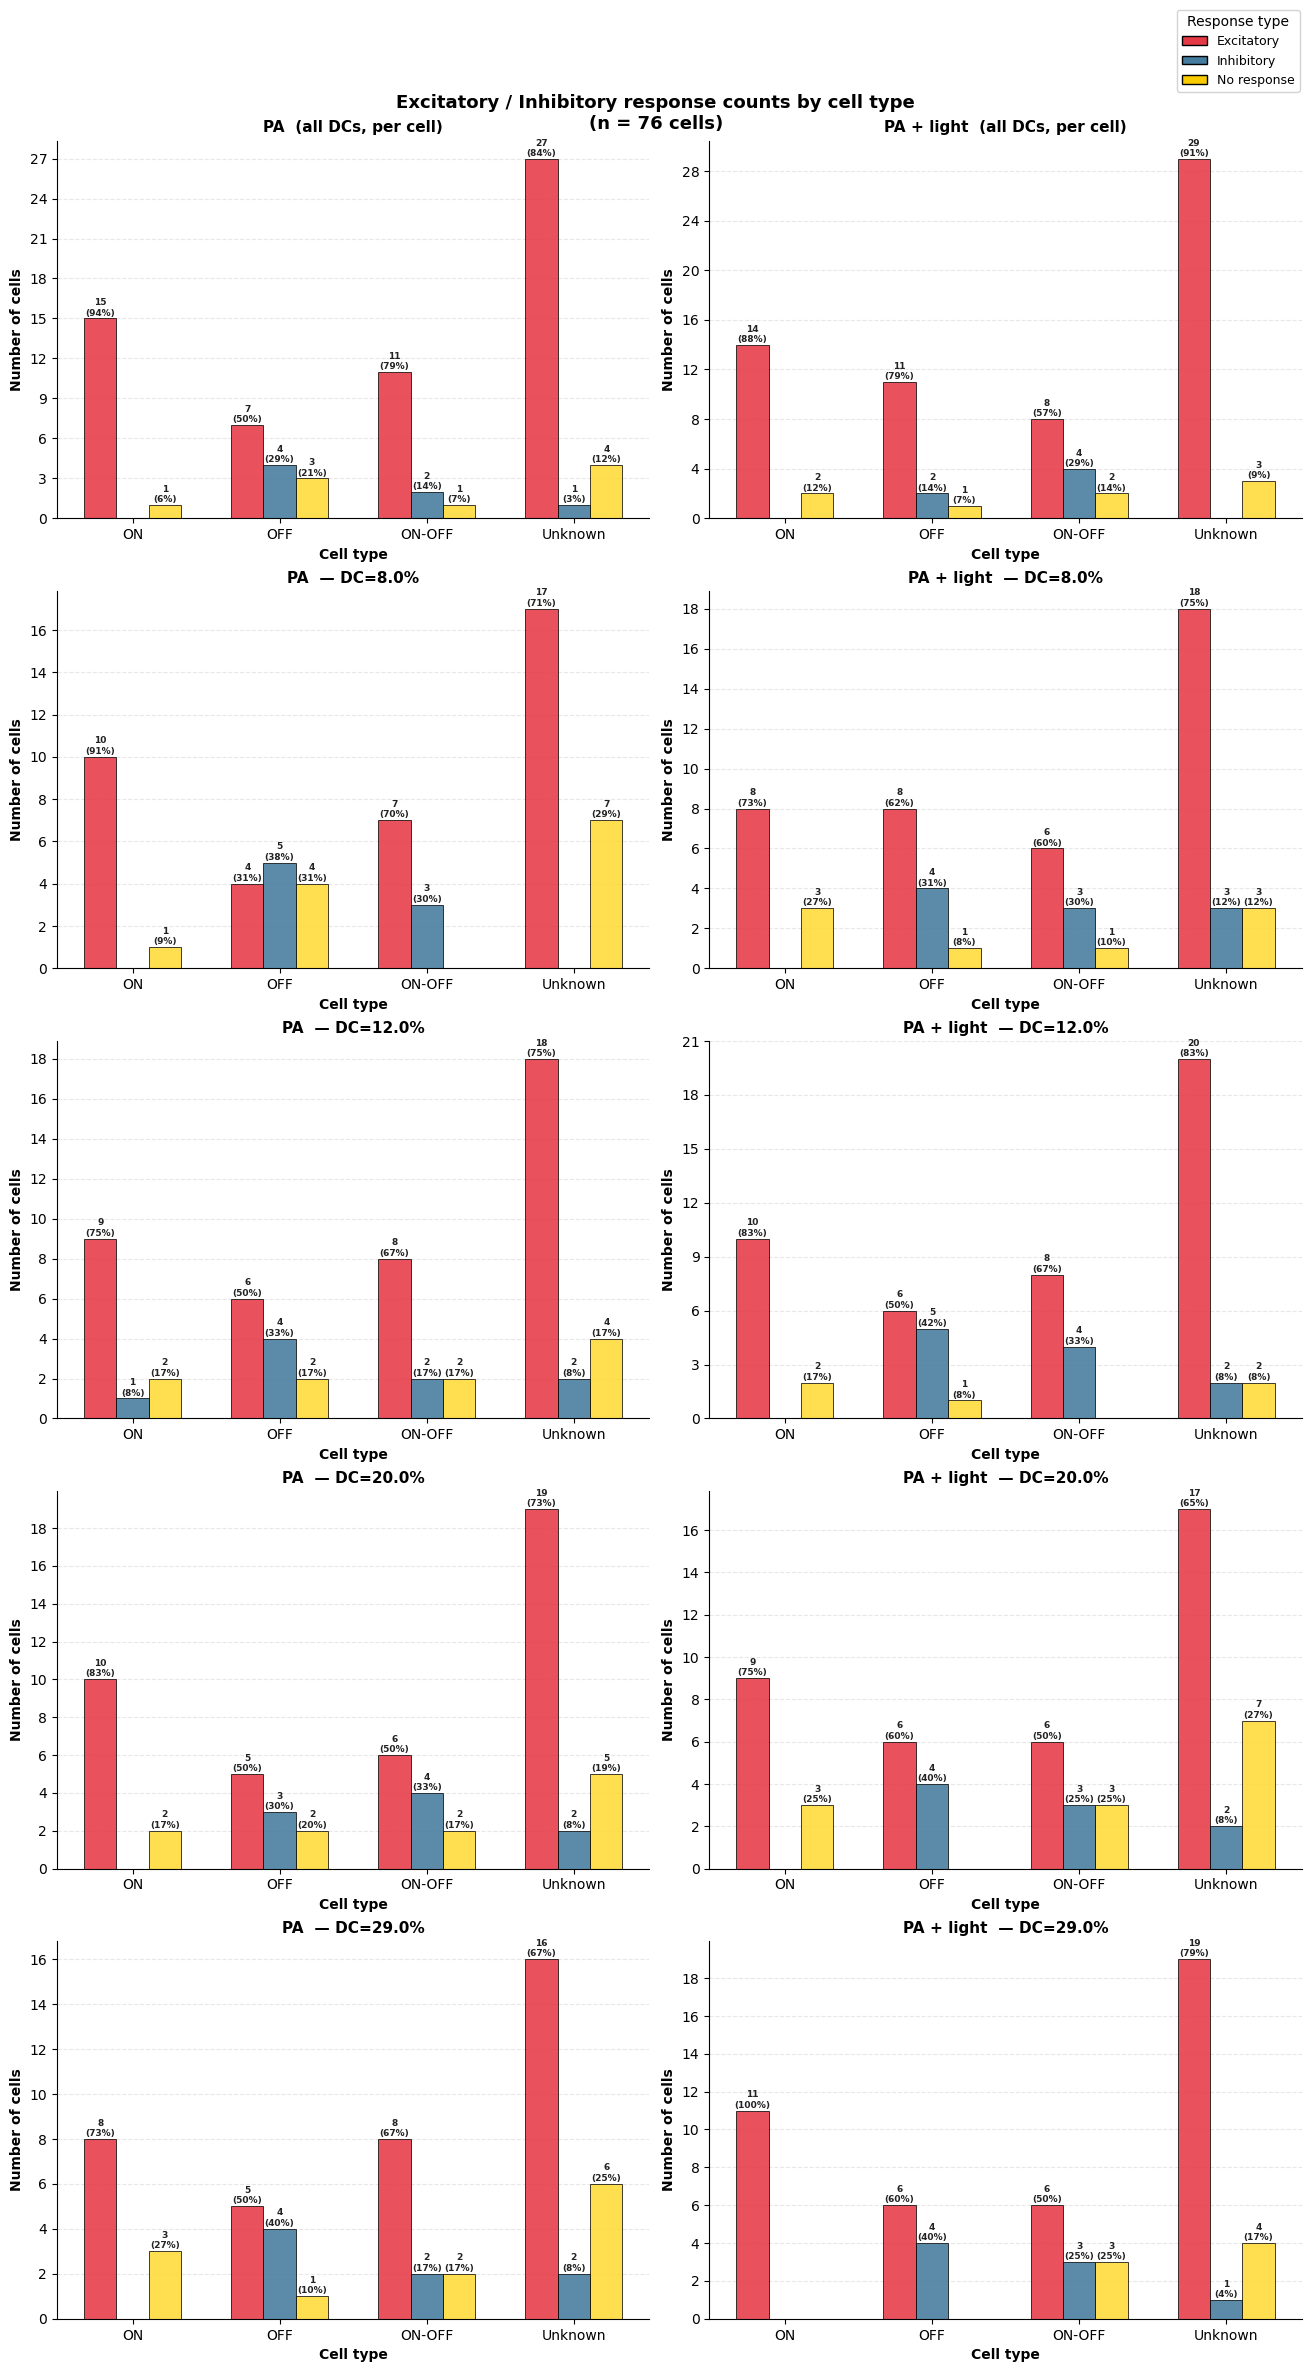

In [37]:
# ============================================================
# RESPONSE TYPE COUNT: ON / OFF / ON-OFF  ×  PA / PA+light
# ── Overall (collapsed across DCs) + per DC ────────────────
# ============================================================
# ── Collect DCs (drop 37) ────────────────────────────────────────────────────
dcs_all = sorted([
    dc for dc in df_merged_wide.index.get_level_values("dc").unique()
    if dc != 37
])

# ── Overall summary ──────────────────────────────────────────────────────────
c_pa, c_pl, p_pa, p_pl = build_counts(df_merged_wide, per_cell=True)
print_summary("OVERALL (majority vote per cell)", c_pa, c_pl, p_pa, p_pl)

# ── Per-DC summaries ─────────────────────────────────────────────────────────
dc_results = {}
for dc in dcs_all:
    df_dc = df_merged_wide.xs(dc, level="dc", drop_level=False)
    c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc = build_counts(df_dc, per_cell=False)
    dc_results[dc] = (c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc)
    print_summary(f"DC = {dc}%", c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc)

# ── Figure layout: row 0 = overall, rows 1..N = per DC ──────────────────────
n_rows = 1 + len(dcs_all)
fig, axes = plt.subplots(
    n_rows, 2,
    figsize=(13, 4.5 * n_rows),
    constrained_layout=True,
)

# Overall row
plot_grouped_bars(axes[0], c_pa, c_pl, p_pa, p_pl, title_suffix="(all DCs, per cell)")

# Per-DC rows
for row_i, dc in enumerate(dcs_all, start=1):
    c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc = dc_results[dc]
    plot_grouped_bars(axes[row_i], c_pa_dc, c_pl_dc, p_pa_dc, p_pl_dc,
                      title_suffix=f"— DC={dc}%")

# Shared legend on the figure
handles = [
    mpatches.Patch(facecolor=RESP_COLORS[r], edgecolor="k", label=r)
    for r in RESP_LABELS
]
fig.legend(
    handles=handles,
    title="Response type",
    loc="upper right",
    bbox_to_anchor=(1.0, 1.05),
    fontsize=9,
    title_fontsize=10,
    framealpha=0.85,
)

fig.suptitle(
    f"Excitatory / Inhibitory response counts by cell type\n"
    f"(n = {len(df_merged_wide.index.get_level_values('cluster_id').unique())} cells)",
    fontsize=13, fontweight="bold", y=1.01,
)

plt.savefig(
    f"{figure_dir}/{session_id}_response_counts_by_cell_type_per_dc.png",
    dpi=150, bbox_inches="tight",
)
print("\n✓ Saved: response_counts_by_cell_type_per_dc.png")
plt.show()


# --------------- WIP ---------------------------------------

Test if there is an offset between the laser and the DMD stims

In [ ]:

fig = make_figure(
    width=1, height=1,
    x_domains={1: [[0.1, 0.9]]},
    y_domains={1: [[0.1, 0.9]]},
)

df_onset = df.laser_burst_onset - df.dmd_burst_onset
df_offset = df.laser_burst_offset - df.dmd_burst_offset

x = np.arange(0, df_onset.size, 1)

fig.add_scatter(
        x=x, 
        y=df_offset,
        mode='markers+lines',
        showlegend=False,
        # name=f'{delay:.0f}',
        marker=dict(color='red')
    )

fig.update_xaxes(
    title_text='burst i'
)
fig.update_yaxes(
    tickvals=np.arange(0, max(df_onset), 1),
    title_text='laser offset - burst offset [ms]'
)

Check how many cells they are per RGC type in this recording

In [ ]:
chirp_rec_nb     = 3
typing_directory = data_dir / Path(f"CellTyping_Analysis_rec_{chirp_rec_nb:03}")
typing_data_path = typing_directory / Path(f"{session_id}_PA-light5_cell_typing_data")
typing_df        = load_obj_as_df(typing_data_path)

types = []
for r in typing_df.baden_type:
    types.append(r.get('name', None))

types_unique = []
count_onoff, count_on, count_off, count_none, total = 0, 0, 0, 0, 0

for x in types:
    if x not in types_unique:
        types_unique.append(x)
count = 0
list_dict = {}

for y in types:
    total += 1
    if x == y:
        count += 1
    if 'ON-OFF' in y:
        count_onoff +=1
    elif 'ON' in y:
        count_on += 1
    elif 'OFF' in y:
        count_off += 1
    else:
        count_none += 1


for x in types_unique:
    for y in types:
        if x == y:
            count += 1
    list_dict.update({x: count})
    count = 0

list_dict.update({'total_ON_OFF': count_onoff,
                  'total_ON': count_on,
                  'total_OFF': count_off,
                  'none': count_none})

list_dict

Generating a summary dataframe (OLD, DISREGARD)

In [ ]:
''' Test WIP '''
##%% optimized single-panel firing rate plotting
x  = 0
pa_lat = []
light_lat = []

for cluster_id in data_io.cluster_df.index.values:

    # Load data for this cluster
    cluster_data = utils.load_obj(
        data_dir / 'bootstrapped' / f'bootstrap_{cluster_id}.pkl'
    )

    # preferred electrode
    ec = pref_ec_dict[cluster_id]

    if ec is None:
        continue

    # Track global y-limits
    y_max = 0

    # Loop over all recordings (all curves go on same axis)
    for rec_i, rec_name in enumerate(selected_rec_names):

        # Filter data
        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()

        if len(d_select) == 0:
            continue

        d_select.sort_values('duty_cycle', inplace=True)

        # Determine stim type: PA vs PA+light
        #if '_PADMD_' in rec_name:
        if '_light_pa_' in rec_name:
            duty_cycles = d_select.laser_duty_cycle.unique()
            mode = 'light'
        #elif '_PA_' in rec_name:
        elif '_pa_' in rec_name:
            duty_cycles = d_select.duty_cycle.unique()
            mode = 'pa'
        else:
            continue

        for dc in duty_cycles:
            # Extract train ID + burst settings
            row0    = d_select.query('laser_duty_cycle == @dc').iloc[0]
            tid     = row0.train_id
            lat     = cells_df.xs(cluster_id)[tid, 'response_latency']
            repfr   = cells_df.xs(cluster_id)[tid, 'response_firing_rate']
            reptype = cells_df.xs(cluster_id)[tid, 'response_type']

            if not np.isnan(lat) :
                if mode == 'light':
                    light_lat.append([cluster_id, ec, dc, lat, repfr, reptype])

                elif mode == 'pa':
                    pa_lat.append([cluster_id, ec, dc, lat, repfr, reptype])

# Summary df for pa responses
df_pa_lat = pd.DataFrame(pa_lat, columns=['cluster_id', 'pref_ec', 'dc', 'pa_response_latency', 'pa_rep_fr','pa_rep_type'])
df_pa_lat.set_index(['cluster_id', 'pref_ec','dc'], inplace = True)

# Summary df for light + pa responses
df_light_lat = pd.DataFrame(light_lat, columns=['cluster_id', 'pref_ec', 'dc', 'light_response_latency', 'light_rep_fr','light_rep_type'])
df_light_lat.set_index(['cluster_id', 'pref_ec','dc'], inplace = True)

# Summary df
lat_df = pd.concat([df_pa_lat, df_light_lat], axis = 1, join = 'outer')

print("\n\nAll clusters processed.\nSummary df generated.\n\t\t\t------ End Of Cell ------")


Plot PA vs light responses (uses bootstrap, disregard)

In [ ]:
df = lat_df.reset_index()

dc_values = sorted(df["dc"].unique())

# Remove dc = 37
df = df[df["dc"] != 37]

dc_values = sorted(df["dc"].unique())
clusters = sorted(df["cluster_id"].unique())

# -------------------
# Figure layout
# -------------------
n_cols = 2
n_rows = int(np.ceil(len(dc_values) / n_cols))

subplot_titles = {
    r + 1: [f"DC = {dc_values[r*n_cols + c]}" if r*n_cols + c < len(dc_values) else ""
            for c in range(n_cols)]
    for r in range(n_rows)
}

fig = utils.simple_fig(
    n_cols=n_cols,
    n_rows=n_rows,
    width=1.4,
    height=0.9 * n_rows,
    subplot_titles=subplot_titles,
    # equal_width_height="x",   # enforce square panels
)

# -------------------
# Axis limits (shared origin at 0)
# -------------------
max_val = max(
    df["pa_response_latency"].max(),
    df["light_response_latency"].max()
)

axis_min = 0
axis_max = max_val * 1.05

# First axes explicitly
fig.update_layout(
    xaxis=dict(range=[axis_min, axis_max]),
    yaxis=dict(range=[axis_min, axis_max], scaleanchor="x", scaleratio=1),
)

# Match all others
fig.update_xaxes(matches="x")
fig.update_yaxes(matches="y", scaleanchor="x", scaleratio=1)

# -------------------
# Plotting
# -------------------
for i, dc in enumerate(dc_values):
    row = i // n_cols + 1
    col = i % n_cols + 1

    sub = df[df["dc"] == dc]

    # per-cluster scatter
    for ci, cluster_id in enumerate(clusters):
        cd = sub[sub["cluster_id"] == cluster_id]
        if cd.empty:
            continue

        color = utils.interp_color(len(clusters), ci, ("qualitative", "Plotly"), alpha=0.9)

        fig.add_trace(
            go.Scatter(
                x=cd["pa_response_latency"],
                y=cd["light_response_latency"],
                mode="markers",
                marker=dict(color=color, size=5),
                name=f"cluster {cluster_id}",
                legendgroup=str(cluster_id),
                showlegend=(i == 0),
            ),
            row=row,
            col=col,
        )

    # identity line
    fig.add_trace(
        go.Scatter(
            x=[axis_min, axis_max],
            y=[axis_min, axis_max],
            mode="lines",
            line=dict(color="black", dash="dash", width=1),
            showlegend=False,
        ),
        row=row,
        col=col,
    )

# -------------------
# Axis labels
# -------------------
fig.update_xaxes(tickmode="auto", showticklabels=True, title_text="PA response latency")
fig.update_yaxes(tickmode="auto", showticklabels=True, title_text="PA + Light response latency")

fig.update_layout(
    xaxis=dict(range=[0, axis_max], zeroline=True),
    yaxis=dict(range=[0, axis_max], scaleanchor="x"),
)

# Match all others
fig.update_xaxes(matches="x")
fig.update_yaxes(matches="y", scaleanchor="x", scaleratio=1)

fig.show()
# sname = figure_dir / f'{session_id}_test_5v9'
# save_fig(fig, sname, formats=['png', 'svg'], scale=3)